# EMA 6938 - Data Science for Materials
## Week 9 Lab Notebook: PCA, Dimensionality Reduction & Clustering

**Name:** *Ryan Tuggle*  
**Date:** *7/10/2026*  
**Kernel:** Python (matds)

---

**Chapters:** Sandfeld Ch. 15  
**Format:** Parts A–G in-class - due **Sunday 11:59 PM**  
**Dataset:** `data/week9_mp_oxides.csv` (instructor-provided)

---

### How to use this notebook
- **Demo cells** (`# LECTURE DEMO`) reproduce examples from the lecture. Run them, understand them.
- **Task cells** (`# YOUR CODE HERE`) require you to write code.
- **Reflection cells** require written markdown answers. Replace the italic placeholder text.

This notebook has 7 parts:

| Part | Title | Connects to |
|------|-------|-------------|
| A | Load & Inspect | Lecture Segment 1|
| B | PCA | Lecture Segment 2|
| C | PCA Projection | Lecture Segment 2|
| D | UMAP | Lecture Segment 3|
| E | Clustering | Lecture Segment 4|
| F | Cluster Annotation | Lecture Segment 5|
| G | Reflection | All segments|

---

**Submission:** Upload this `.ipynb` file to Canvas. Run `Kernel → Restart & Run All` before submitting to confirm all cells execute cleanly.

> **AI tool disclosure:** If you used any AI coding assistant (GitHub Copilot, ChatGPT, etc.) while completing this notebook, describe briefly which tool, for what purpose, and what you verified yourself. Delete this line if no AI tools were used.

I used MS copilot for the purpose of debugging my code and helping with my grammar. 

In [1]:
# Cell 0 — Environment check
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
SEED = 42
print("Core imports OK")

try:
    import umap
    print("umap-learn OK")
except ImportError:
    print("umap-learn not found - run: pip install umap-learn")

Core imports OK
umap-learn OK


---
## Part A - Load & Inspect

### A1: Load the dataset

In [2]:
# Cell A1
# LECTURE DEMO
df = pd.read_csv('data/week9_mp_oxides.csv')
print(f"Shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df[['formula','band_gap','Ef_eV_atom','crystal_system']].head())
print(f"\nBand gap - mean: {df['band_gap'].mean():.2f} eV  |  fraction metallic: {(df['band_gap']==0).mean():.1%}")

Shape: (8000, 140)

First 5 rows:
        formula  band_gap  Ef_eV_atom crystal_system
0       LiFePO4    3.6826   -2.381284     Monoclinic
1    Li2MnCo3O8    0.0000   -1.673545     Monoclinic
2  Li3Co2Ni3O10    0.0000   -1.330458     Monoclinic
3     Gd2As4O11    2.4840   -2.368477     Monoclinic
4          KIO4    2.3475   -1.166622     Tetragonal

Band gap - mean: 1.68 eV  |  fraction metallic: 21.9%


### A2: Set up the feature matrix X

In [3]:
# Cell A2
# LECTURE DEMO
non_feature_cols = ['mp_id','formula','band_gap','Ef_eV_atom','volume_A3',
                    'density_g_cm3','crystal_system','composition','is_metallic','is_insulating']
feature_cols = [c for c in df.columns
                if c not in non_feature_cols and df[c].dtype in ['float64','float32']]

print(f"MAGPIE features: {len(feature_cols)}")

X_raw = df[feature_cols].values
mask  = ~np.isnan(X_raw).any(axis=1)
X_raw = X_raw[mask]
df_clean = df[mask].reset_index(drop=True)

print(f"Final X shape: {X_raw.shape}")
print(f"Dropped {(~mask).sum()} rows with NaN")

MAGPIE features: 132
Final X shape: (8000, 132)
Dropped 0 rows with NaN


### A3: Standardise X

> **Important:** For unsupervised learning we standardise using ALL available data. There is no train/test split here because we are not predicting a target.

In [4]:
# Cell A3
# LECTURE DEMO
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print(f"X_scaled mean (should be ~0): {X_scaled.mean():.4f}")
print(f"X_scaled std  (should be ~1): {X_scaled.std():.4f}")

X_scaled mean (should be ~0): 0.0000
X_scaled std  (should be ~1): 0.9653


---
## Part B - PCA

### B1: Fit PCA and plot the scree curve

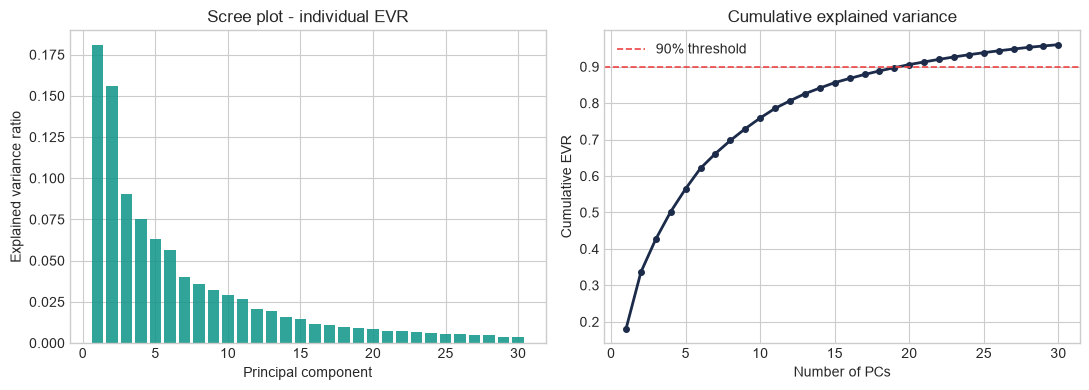

PCs needed for 90% variance: 20
Variance explained by PC1: 18.1%
Variance explained by PC2: 15.6%


In [5]:
# Cell B1
# LECTURE DEMO
pca = PCA(n_components=30, random_state=SEED)
Z_pca = pca.fit_transform(X_scaled)

evr = pca.explained_variance_ratio_
cumevr = evr.cumsum()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.bar(range(1, 31), evr, color='#0D9488', alpha=0.85)
ax1.set_xlabel('Principal component')
ax1.set_ylabel('Explained variance ratio')
ax1.set_title('Scree plot - individual EVR')

ax2.plot(range(1, 31), cumevr, marker='o', ms=4, color='#1C2B4A', lw=2)
ax2.axhline(0.90, color='#EF4444', ls='--', lw=1.2, label='90% threshold')
ax2.set_xlabel('Number of PCs')
ax2.set_ylabel('Cumulative EVR')
ax2.set_title('Cumulative explained variance')
ax2.legend()

plt.tight_layout()
plt.savefig('B1_scree.png', dpi=150)
plt.show()

n90 = np.searchsorted(cumevr, 0.90) + 1
print(f"PCs needed for 90% variance: {n90}")
print(f"Variance explained by PC1: {evr[0]:.1%}")
print(f"Variance explained by PC2: {evr[1]:.1%}")

### B2: Biplot - PC1 vs PC2 with loading vectors

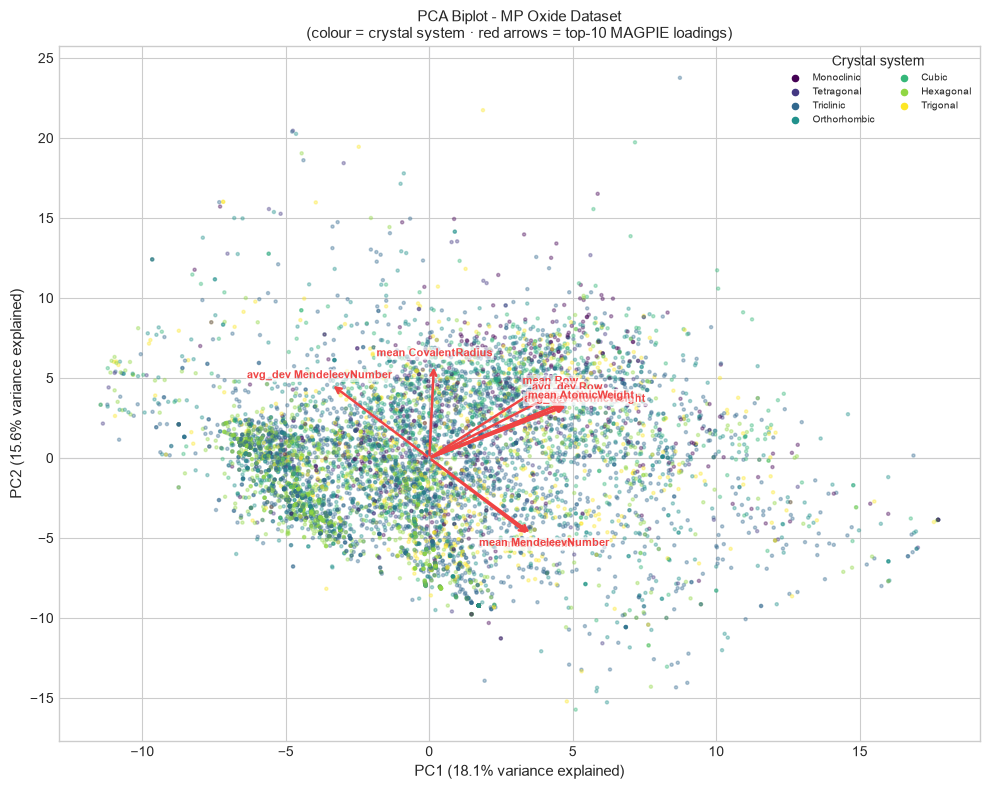


Top-10 MAGPIE features by loading magnitude on PC1+PC2:
Rank  Feature                                 PC1 loading  PC2 loading  Magnitude
--------------------------------------------------------------------------------
1     mean MendeleevNumber                        +0.1228      -0.1634     0.2044
2     mean Column                                 +0.1198      -0.1654     0.2042
3     mean AtomicWeight                           +0.1625      +0.1196     0.2018
4     avg_dev AtomicWeight                        +0.1666      +0.1133     0.2015
5     mean Number                                 +0.1622      +0.1195     0.2015
6     avg_dev Number                              +0.1652      +0.1146     0.2011
7     mean CovalentRadius                         +0.0056      +0.2008     0.2009
8     avg_dev Row                                 +0.1478      +0.1355     0.2005
9     avg_dev MendeleevNumber                     -0.1177      +0.1586     0.1975
10    mean Row                            

In [6]:
# Cell B2 — PCA biplot: crystal system + top-10 loading vectors
# Two fixes vs. a naive biplot:
#   1. Arrows scaled to ~25% of the scatter cloud radius so they are always visible
#   2. A ranked table of loadings printed below for easy reading

fig, ax = plt.subplots(figsize=(10, 8))

# ── Scatter: materials coloured by crystal system ────────────────────────
cs = df_clean['crystal_system'].fillna('Unknown')
cs_cats = cs.unique()
cmap_cat = plt.get_cmap('viridis', len(cs_cats))
cs_codes = pd.Categorical(cs).codes

sc = ax.scatter(Z_pca[:, 0], Z_pca[:, 1],
                c=cs_codes, cmap='viridis', s=5, alpha=0.35, zorder=1)

# ── Loading vectors ───────────────────────────────────────────────────────
# Raw loadings: pca.components_.T  shape (n_features, n_components)
# We use ONLY the signs and relative magnitudes — we scale the arrow length
# to 25% of the visible axis radius so all arrows are always readable,
# regardless of how spread the scatter is.
loadings_raw = pca.components_[:2].T          # (132, 2)
top10_idx = np.argsort(np.sqrt(loadings_raw[:,0]**2 + loadings_raw[:,1]**2))[-10:]

# Scale factor: map the largest-magnitude loading to 25% of axis radius
axis_radius = max(np.abs(Z_pca[:, 0]).max(), np.abs(Z_pca[:, 1]).max())
max_loading  = np.sqrt(loadings_raw[top10_idx, 0]**2 + loadings_raw[top10_idx, 1]**2).max()
arrow_scale  = 0.25 * axis_radius / max_loading   # always visible

for i in top10_idx:
    dx = loadings_raw[i, 0] * arrow_scale
    dy = loadings_raw[i, 1] * arrow_scale
    ax.annotate(
        '', xy=(dx, dy), xytext=(0, 0),
        arrowprops=dict(arrowstyle='->', color='#EF4444', lw=1.8),
        zorder=3
    )
    label = feature_cols[i].replace('MagpieData ', '')
    ax.text(dx * 1.12, dy * 1.12, label,
            fontsize=8, color='#EF4444', fontweight='bold',
            ha='center', va='center', zorder=4,
            bbox=dict(fc='white', ec='none', alpha=0.6, pad=1))

# ── Axes, legend, title ──────────────────────────────────────────────────
ax.set_xlabel(f'PC1 ({evr[0]:.1%} variance explained)', fontsize=11)
ax.set_ylabel(f'PC2 ({evr[1]:.1%} variance explained)', fontsize=11)
ax.set_title(
    'PCA Biplot - MP Oxide Dataset\n'
    '(colour = crystal system · red arrows = top-10 MAGPIE loadings)',
    fontsize=11
)
ax.axhline(0, color='#CBD5E1', lw=0.8, zorder=0)
ax.axvline(0, color='#CBD5E1', lw=0.8, zorder=0)

handles = [plt.scatter([], [], c=[cmap_cat(j)], s=20, label=cat)
           for j, cat in enumerate(cs_cats)]
ax.legend(handles=handles, fontsize=7, title='Crystal system',
          ncol=2, loc='upper right')

plt.tight_layout()
plt.savefig('B2_biplot.png', dpi=150)
plt.show()

# ── Ranked loading table — easier to read than arrows alone ─────────────
print("\nTop-10 MAGPIE features by loading magnitude on PC1+PC2:")
print(f"{'Rank':<5} {'Feature':<38} {'PC1 loading':>12} {'PC2 loading':>12} {'Magnitude':>10}")
print("-" * 80)
magnitudes = np.sqrt(loadings_raw[:, 0]**2 + loadings_raw[:, 1]**2)
sorted_idx = np.argsort(magnitudes)[::-1][:10]
for rank, i in enumerate(sorted_idx, 1):
    fname = feature_cols[i].replace('MagpieData ', '')
    l1    = loadings_raw[i, 0]
    l2    = loadings_raw[i, 1]
    mag   = magnitudes[i]
    print(f"{rank:<5} {fname:<38} {l1:>+12.4f} {l2:>+12.4f} {mag:>10.4f}")

print("\nInterpretation guide:")
print("  PC1 loading sign: positive = feature increases along PC1 direction")
print("  PC2 loading sign: positive = feature increases along PC2 direction")
print("  Magnitude: how strongly this feature contributes to the 2D projection")

### B3: Report top loadings

> Fill in the table below after running B2.

In [7]:
# Cell B3 - Top 3 loading features on PC1 (by absolute magnitude)
# LECTURE DEMO
print("Top 3 loading features on PC1:")
pc1_load = pd.Series(pca.components_[0], index=feature_cols)
print(pc1_load.abs().nlargest(3).round(4))

print("\nTop 3 loading features on PC2:")
pc2_load = pd.Series(pca.components_[1], index=feature_cols)
print(pc2_load.abs().nlargest(3).round(4))

Top 3 loading features on PC1:
MagpieData mean NValence           0.1723
MagpieData avg_dev AtomicWeight    0.1666
MagpieData avg_dev Number          0.1652
dtype: float64

Top 3 loading features on PC2:
MagpieData mean CovalentRadius       0.2008
MagpieData avg_dev CovalentRadius    0.1885
MagpieData mean Column               0.1654
dtype: float64


### B4: Biplot coloured by band gap

Plot the same biplot but colour the scatter by band_gap (continuous colourmap). Describe the direction of the band_gap gradient in the PC space.

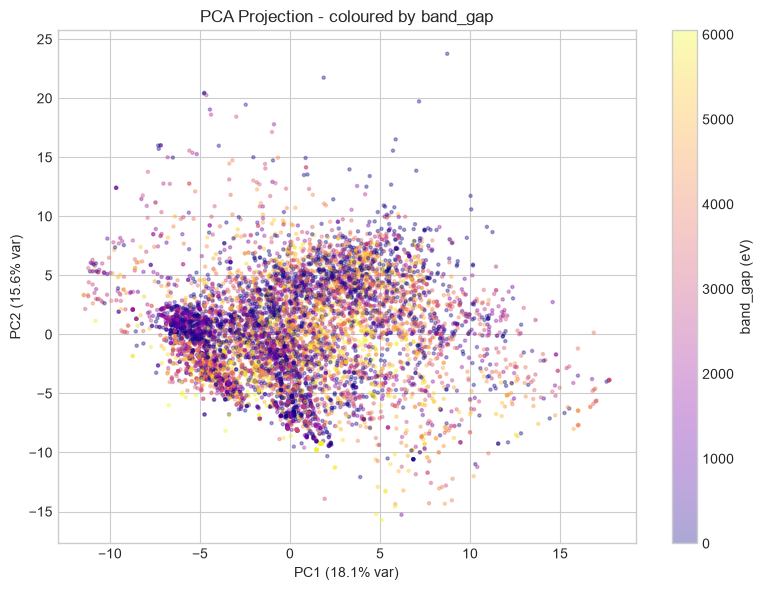

In [8]:
# Cell B4
# TASK CELL
fig, ax = plt.subplots(figsize=(8, 6))

cs = df_clean['band_gap'].fillna('Unknown')
cs_cats = cs.unique()
cmap_cat = plt.get_cmap('plasma', len(cs_cats))
cs_codes = pd.Categorical(cs).codes

sc = ax.scatter(Z_pca[:, 0], Z_pca[:, 1],
                c=cs_codes, 
                cmap='plasma', 
                s=5, 
                alpha=0.35, 
                zorder=1
)
plt.colorbar(sc, ax=ax, label='band_gap (eV)')
ax.set_xlabel(f'PC1 ({evr[0]:.1%} var)')
ax.set_ylabel(f'PC2 ({evr[1]:.1%} var)')
ax.set_title('PCA Projection - coloured by band_gap')
plt.tight_layout()
plt.savefig('B4_biplot_bandgap.png', dpi=150)
plt.show()
# YOUR CODE: scatter Z_pca[:,0] vs Z_pca[:,1], coloured by df_clean['band_gap']
# Use cmap='plasma', vmin=0, vmax=8
# Add a colorbar labelled 'Band gap (eV)'
# Save as B4_biplot_bandgap.png

**Reflection B4 - fill in this cell:**

Looking at the band_gap gradient in the biplot: in which direction (positive PC1? positive PC2?) do wide-gap insulators plot relative to metals? Which loading feature is most aligned with that direction?

*Your answer here*

Wide gap insulators plot in the positive PC1 direction relative to the metals. The loading feature most aligned with that direction is mean Nvalence. This is likely because a higher average of valence electrons correlates strongly with having more nonmetal atoms in the formula that are of high electronegativity. This creates more ionic bonding character and leads the larger bandgap energies. 

---
## Part C - PCA Projection Scatters

### C1: PC1 vs PC2 coloured by formation energy

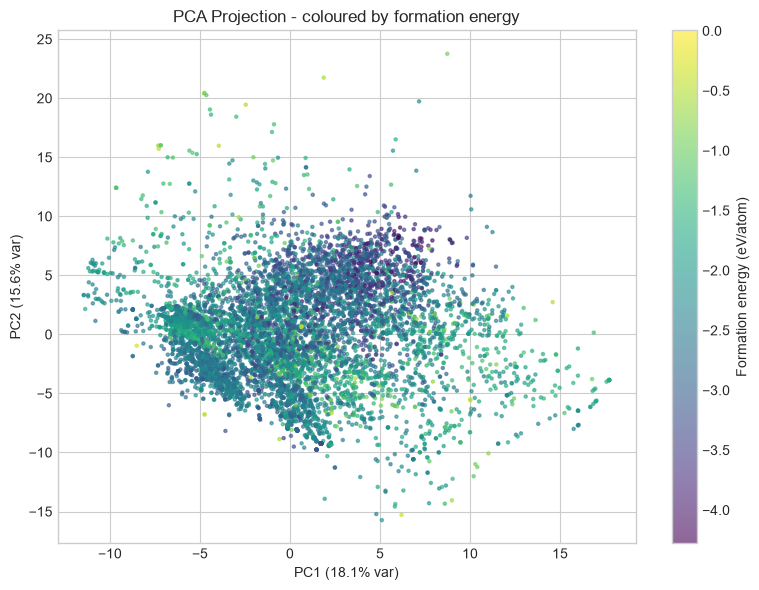

In [9]:
# Cell C1
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(Z_pca[:, 0], Z_pca[:, 1],
                c=df_clean['Ef_eV_atom'], cmap='viridis',
                s=5, alpha=0.6)
plt.colorbar(sc, ax=ax, label='Formation energy (eV/atom)')
ax.set_xlabel(f'PC1 ({evr[0]:.1%} var)')
ax.set_ylabel(f'PC2 ({evr[1]:.1%} var)')
ax.set_title('PCA Projection - coloured by formation energy')
plt.tight_layout()
plt.savefig('C1_pca_formation_energy.png', dpi=150)
plt.show()

**Reflection C1 - fill in this cell:**

Compare this formation-energy coloring to your B4 band-gap plot. Do the two properties show similar or different spatial structure across PC1-PC2?

The two properties show similar spatial structure across PC1-PC2. The two are shaped very similarly with the color gradient also being similar. 

### C2: PC1 vs PC2 coloured by crystal system

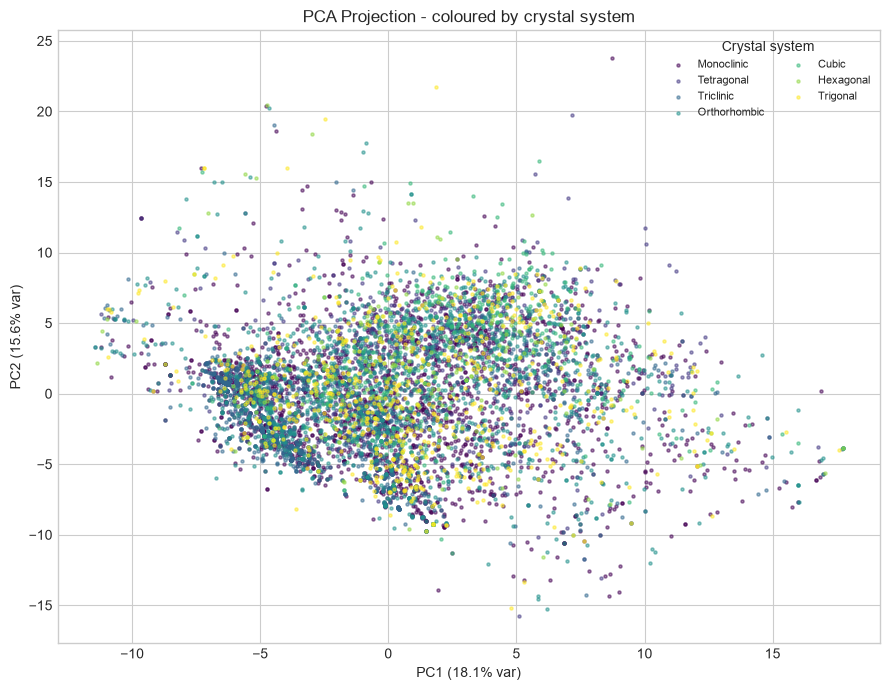

In [10]:
# Cell C2
# LECTURE DEMO
crs = df_clean['crystal_system'].fillna('Unknown')
crs_cats = crs.unique()
cmap_cat = plt.get_cmap('viridis', len(crs_cats))
fig, ax = plt.subplots(figsize=(9, 7))
for j, cat in enumerate(crs_cats):
    mask_c = (crs == cat).values
    ax.scatter(Z_pca[mask_c, 0], Z_pca[mask_c, 1],
               c=[cmap_cat(j)], s=5, alpha=0.5, label=cat)
ax.set_xlabel(f'PC1 ({evr[0]:.1%} var)')
ax.set_ylabel(f'PC2 ({evr[1]:.1%} var)')
ax.set_title('PCA Projection - coloured by crystal system')
ax.legend(fontsize=8, title='Crystal system', ncol=2)
plt.tight_layout()
plt.savefig('C2_pca_crystal.png', dpi=150)
plt.show()

### C3: Task - PC3 vs PC4

> Does PC3 vs PC4 reveal any structure that is hidden in PC1–PC2?

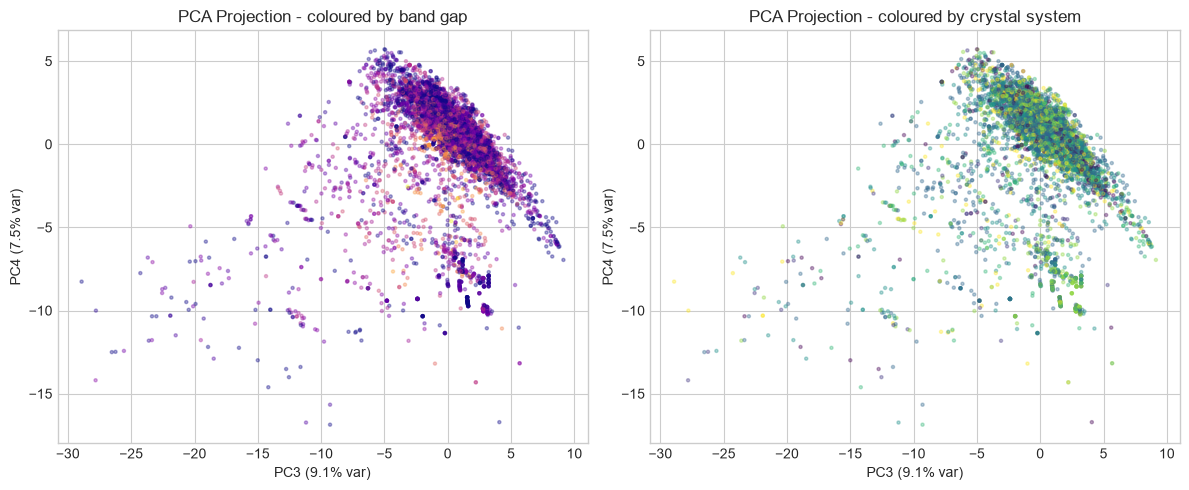

In [11]:
# Cell C3
# TASK CELL
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# YOUR CODE:
# Left panel: scatter Z_pca[:,2] vs Z_pca[:,3] coloured by band_gap
axes[0].scatter(Z_pca[:, 2], Z_pca[:, 3],
                c=df_clean['band_gap'], cmap='plasma', s=5, alpha=0.35)
axes[0].set_xlabel(f'PC3 ({evr[2]:.1%} var)')
axes[0].set_ylabel(f'PC4 ({evr[3]:.1%} var)')
axes[0].set_title('PCA Projection - coloured by band gap')  
axes[1].scatter(Z_pca[:, 2], Z_pca[:, 3],
                c=pd.Categorical(df_clean['crystal_system']).codes, cmap='viridis', s=5, alpha=0.35)
axes[1].set_xlabel(f'PC3 ({evr[2]:.1%} var)')
axes[1].set_ylabel(f'PC4 ({evr[3]:.1%} var)')
axes[1].set_title('PCA Projection - coloured by crystal system')

plt.tight_layout()
plt.savefig('C3_pca_pc3pc4.png', dpi=150)

# Right panel: same but coloured by crystal_system
# Titles and axis labels with EVR percentages
# Save as C3_pca_pc3pc4.png

**Reflection C3 - fill in this cell:**

Comparing PC1–PC2 to PC3–PC4: does the crystal system separation become clearer or murkier in the higher PCs? Why might that be physically?

The crystal system separation becomes murkier at higher PCs. This probably means that the most heavily loaded features for these higher PCs are ones that don't vary much with crystal system. 

---
## Part D - UMAP

### D1: Fit UMAP and save the embedding

> **Runtime note:** UMAP on 10k entries takes 2–5 min. Subsample to 3,000 for a quick test run first.

In [12]:
# Cell D1 - Optional subsample for a quick test - comment out for full run
# df_clean = df_clean.sample(3000, random_state=SEED).reset_index(drop=True)
# X_scaled = scaler.transform(df_clean[feature_cols].values)
# LECTURE DEMO

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    random_state=SEED,
    verbose=True
)
embedding = reducer.fit_transform(X_scaled)

np.save('D1_umap_embedding.npy', embedding)
print(f"Embedding shape: {embedding.shape}")
print("Saved to D1_umap_embedding.npy")

UMAP(n_jobs=1, random_state=42, verbose=True)
Sun Jul 12 16:47:32 2026 Construct fuzzy simplicial set
Sun Jul 12 16:47:32 2026 Finding Nearest Neighbors
Sun Jul 12 16:47:32 2026 Building RP forest with 9 trees
Sun Jul 12 16:47:38 2026 NN descent for 13 iterations
	 1  /  13
	 2  /  13
	 3  /  13
	Stopping threshold met -- exiting after 3 iterations
Sun Jul 12 16:47:46 2026 Finished Nearest Neighbor Search
Sun Jul 12 16:47:50 2026 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Sun Jul 12 16:48:01 2026 Finished embedding
Embedding shape: (8000, 2)
Saved to D1_umap_embedding.npy


### D1b: t-SNE - local structure vs. UMAP

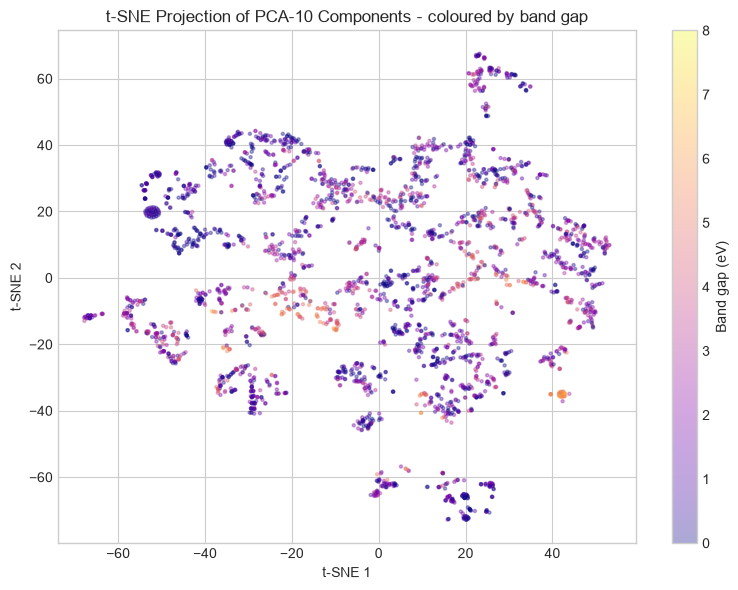

In [13]:
# Cell D1b — t-SNE on PCA-10 components
# We run t-SNE on Z10 (PCA-reduced space) rather than raw 132D features —
# this is standard practice: PCA removes noise first, t-SNE then finds
# nonlinear structure in the reduced space.
#
# Subsample to 3,000 for speed (t-SNE is O(n²) in memory and slow for n > 5,000)
# YOUR CODE: 
from sklearn.manifold import TSNE
pca10 = PCA(n_components=10, random_state=SEED)
Z10 = pca10.fit_transform(X_scaled)

tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=SEED)
Z10_tsne = tsne.fit_transform(Z10[:3000])

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(Z10_tsne[:, 0], Z10_tsne[:, 1],
                c=df_clean['band_gap'][:3000], cmap='plasma', vmin=0, vmax=8, s=5, alpha=0.35)
plt.colorbar(sc, ax=ax, label='Band gap (eV)')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_title('t-SNE Projection of PCA-10 Components - coloured by band gap')
plt.tight_layout()
plt.savefig('D1b_tsne.png', dpi=150)
plt.show()
#            on Z10[:3000] and scatter the result coloured by df_clean['band_gap'][:3000]
#            using cmap='plasma', vmin=0, vmax=8
#            Save as 'D1b_tsne.png'

# YOUR CODE HERE

**Reflection D1b - fill in this cell:**

Does t-SNE produce tighter, more fragmented clusters than UMAP? Does the global layout (which chemical family is near which) look the same or different compared to your Part D2 UMAP coloured by band gap? Why might t-SNE fragment a single broad chemical family into several islands?

t-SNE produces clusters that are more spread out than in UMAP but the clusters themselves are tightly packed. The global layout looks different compared to UMAP. t-SNE might fragment a single chemical family into several islands because the tuning paramter 'perplexity' is causing the algorithm to magnify differences between points in a cluster so only the closest neighbors in the cluster are preserved and the others get split off. 

### D2: UMAP coloured by band gap

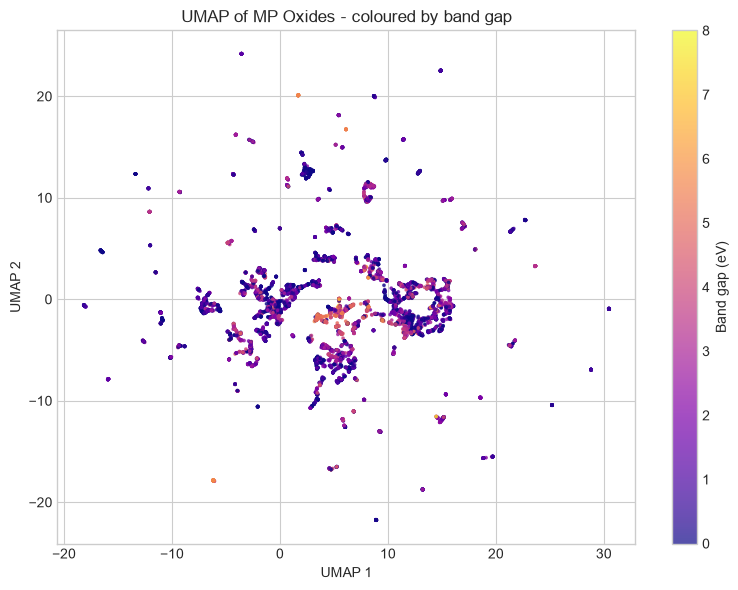

In [14]:
# Cell D2
# LECTURE DEMO
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(embedding[:, 0], embedding[:, 1],
                c=df_clean['band_gap'], cmap='plasma',
                vmin=0, vmax=8, s=3, alpha=0.7)
plt.colorbar(sc, ax=ax, label='Band gap (eV)')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title('UMAP of MP Oxides - coloured by band gap')
plt.tight_layout()
plt.savefig('D2_umap_bandgap.png', dpi=150)
plt.show()

### D3: UMAP coloured by formation energy

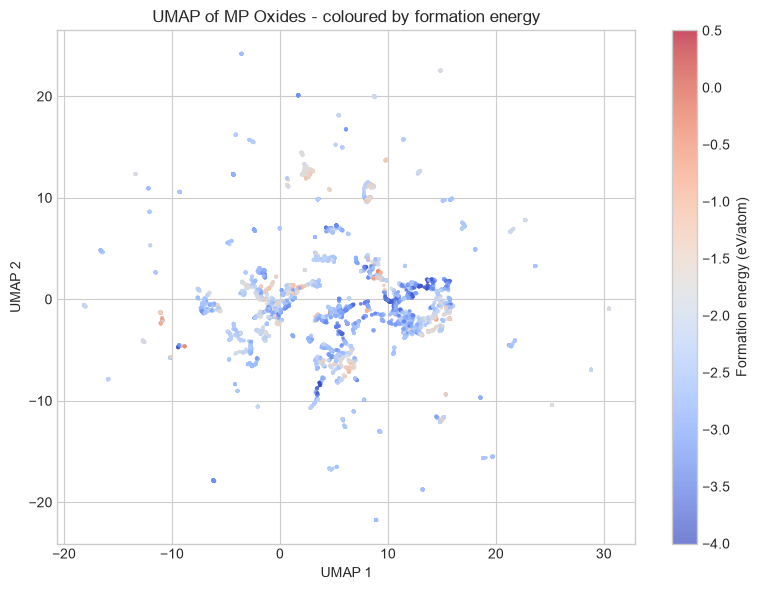

In [15]:
# Cell D3
# LECTURE DEMO
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(embedding[:, 0], embedding[:, 1],
                c=df_clean['Ef_eV_atom'], cmap='coolwarm',
                vmin=-4, vmax=0.5, s=3, alpha=0.7)
plt.colorbar(sc, ax=ax, label='Formation energy (eV/atom)')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title('UMAP of MP Oxides - coloured by formation energy')
plt.tight_layout()
plt.savefig('D3_umap_ef.png', dpi=150)
plt.show()

### D4: UMAP coloured by crystal system

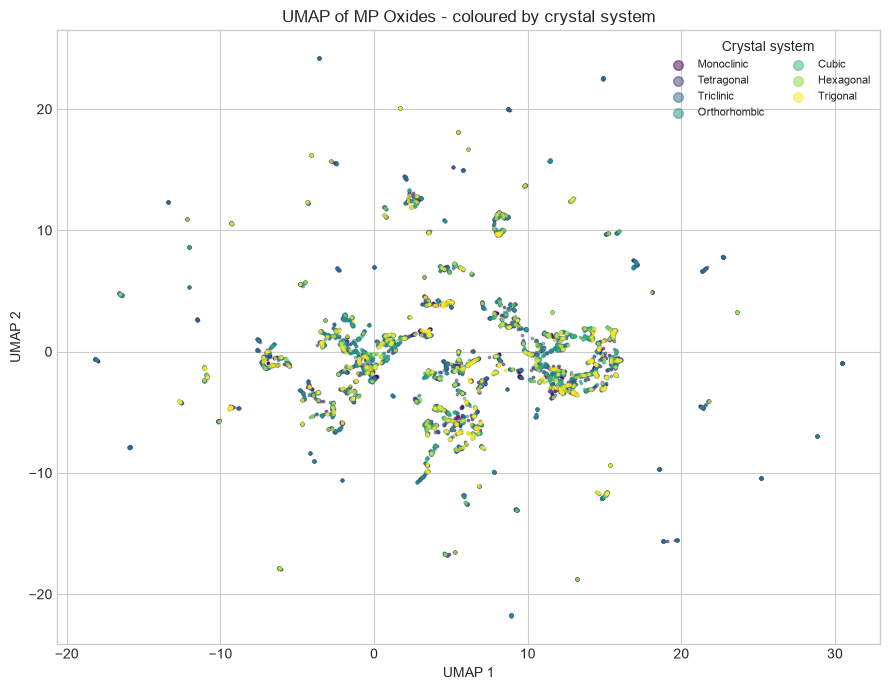

In [16]:
# Cell D4
# LECTURE DEMO
fig, ax = plt.subplots(figsize=(9, 7))
for j, cat in enumerate(crs_cats):
    mask_c = (df_clean['crystal_system'].fillna('Unknown') == cat).values
    ax.scatter(embedding[mask_c, 0], embedding[mask_c, 1],
               c=[cmap_cat(j)], s=3, alpha=0.5, label=cat)
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title('UMAP of MP Oxides - coloured by crystal system')
ax.legend(fontsize=8, title='Crystal system', ncol=2, markerscale=4)
plt.tight_layout()
plt.savefig('D4_umap_crystal.png', dpi=150)
plt.show()

### D5: Task - n_neighbors sensitivity

> Run UMAP with `n_neighbors=5` and `n_neighbors=50` and compare to the default (15).

UMAP(n_jobs=1, n_neighbors=5, random_state=42, verbose=True)
Sun Jul 12 16:48:11 2026 Construct fuzzy simplicial set
Sun Jul 12 16:48:11 2026 Finding Nearest Neighbors
Sun Jul 12 16:48:11 2026 Building RP forest with 9 trees
Sun Jul 12 16:48:12 2026 NN descent for 13 iterations
	 1  /  13
	 2  /  13
	Stopping threshold met -- exiting after 2 iterations
Sun Jul 12 16:48:12 2026 Finished Nearest Neighbor Search
Sun Jul 12 16:48:12 2026 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Sun Jul 12 16:48:18 2026 Finished embedding
UMAP(n_jobs=1, random_state=42, verbose=True)
Sun Jul 12 16:48:19 2026 Construct fuzzy simplicial set
Sun Jul 12 16:48:19 2026 Finding Nearest Neighbors
Sun Jul 12 16:48:19 2026 Building RP forest with 9 trees
Sun Jul 12 16:48:19 2026 NN descent for 13 iterations
	 1  /  13
	 2  /  13
	 3  /  13
	Stopping threshold met -- exiting after 3 iterations
Sun Jul 12 16:48:19 2026 Finished Nearest Neighbor Search
Sun Jul 12 16:48:19 2026 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Sun Jul 12 16:48:30 2026 Finished embedding
UMAP(n_jobs=1, n_neighbors=50, random_state=42, verbose=True)
Sun Jul 12 16:48:30 2026 Construct fuzzy simplicial set
Sun Jul 12 16:48:30 2026 Finding Nearest Neighbors
Sun Jul 12 16:48:30 2026 Building RP forest with 9 trees
Sun Jul 12 16:48:30 2026 NN descent for 13 iterations
	 1  /  13
	 2  /  13
	Stopping threshold met -- exiting after 2 iterations
Sun Jul 12 16:48:32 2026 Finished Nearest Neighbor Search
Sun Jul 12 16:48:32 2026 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Sun Jul 12 16:48:46 2026 Finished embedding


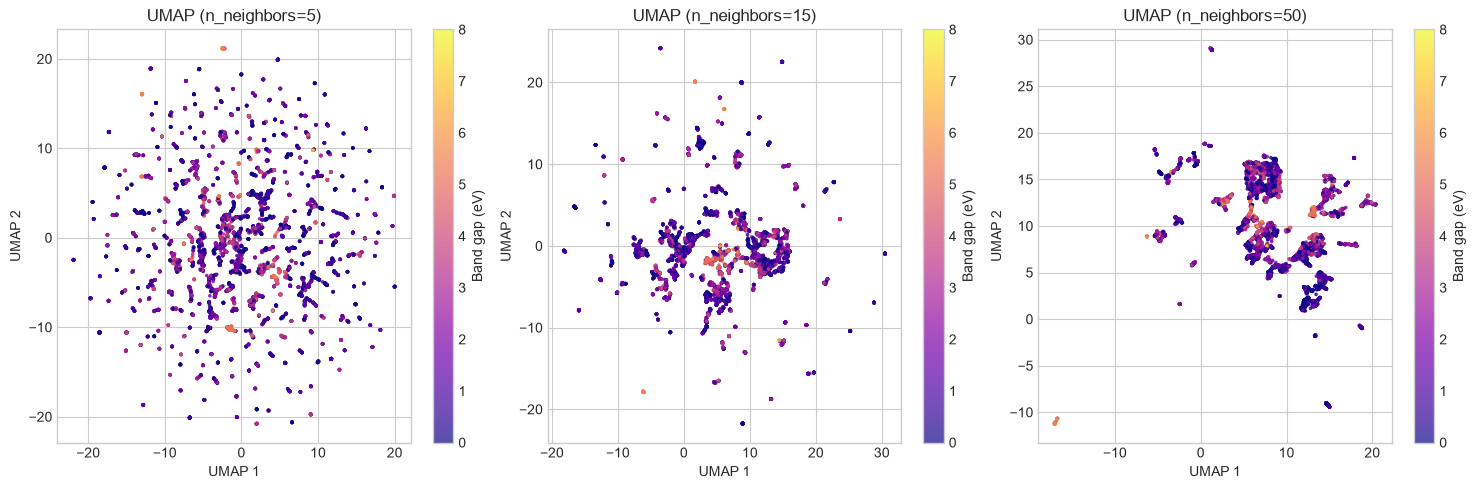

In [17]:
# Cell D5
# TASK CELL
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# YOUR CODE: for each n_neighbors value in [5, 15, 50]:
for i, n_neighbors in enumerate([5, 15, 50]):
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=n_neighbors,
        min_dist=0.1,
        random_state=SEED,
        verbose=True
    )
    embedding = reducer.fit_transform(X_scaled)
    
    sc = axes[i].scatter(embedding[:, 0], embedding[:, 1],
                         c=df_clean['band_gap'], cmap='plasma',
                         vmin=0, vmax=8, s=3, alpha=0.7)
    axes[i].set_xlabel('UMAP 1')
    axes[i].set_ylabel('UMAP 2')
    axes[i].set_title(f'UMAP (n_neighbors={n_neighbors})')
    plt.tight_layout()
    plt.colorbar(sc, ax=axes[i], label='Band gap (eV)')
    plt.savefig('D5_umap_neighbors.png', dpi=150)
#   - run UMAP with that n_neighbors (keep min_dist=0.1, random_state=SEED)
#   - scatter the embedding on the corresponding axis, coloured by df_clean['band_gap']
#   - use cmap='plasma', vmin=0, vmax=8
#   - title each panel with its n_neighbors value
# Save the full 3-panel figure as 'D5_umap_neighbors.png'

**Reflection D5 - fill in this cell:**

How does the embedding change as `n_neighbors` increases from 5 to 50? What does a very small `n_neighbors` emphasise? What does a large value emphasise? Which would you choose for identifying broad chemical families vs. finding micro-clusters?

As the n_neighbors increases from 5 to 50, the embedding changes in that the clusters become more closely spaced together. A very small n_neighbors emphasizes points that are very similar in the feature space to one another, while a large value emphasizes more the global structure between clusters. For broad chemical families I would go with a higher n_neighbors and for finding micro-clusters I would go with a small n_neighbors. 

---
## Part E - Clustering

### E1: k-means on PCA-10 - elbow and silhouette

Cumulative variance in 10 PCs: 75.9%


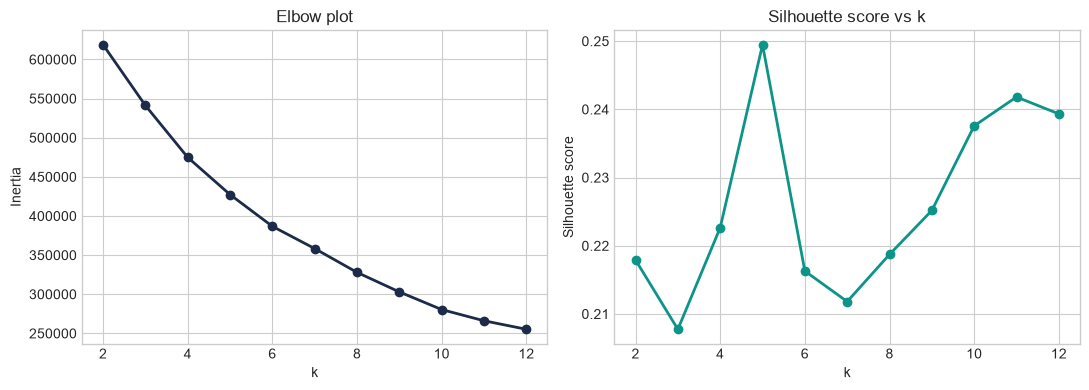


Optimal k by silhouette: 5  (silhouette = 0.249)


In [18]:
# Cell E1 - Project onto top-10 PCs first (better for clustering than raw 132D)
# LECTURE DEMO
pca10 = PCA(n_components=10, random_state=SEED)
Z10 = pca10.fit_transform(X_scaled)
print(f"Cumulative variance in 10 PCs: {pca10.explained_variance_ratio_.sum():.1%}")

inertias, sils = [], []
K_range = range(2, 13)

for k in K_range:
    km = KMeans(n_clusters=k, n_init=20, random_state=SEED)
    labels = km.fit_predict(Z10)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(Z10, labels, sample_size=2000, random_state=SEED))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(K_range, inertias, marker='o', color='#1C2B4A', lw=2)
ax1.set_xlabel('k'); ax1.set_ylabel('Inertia'); ax1.set_title('Elbow plot')

ax2.plot(K_range, sils, marker='o', color='#0D9488', lw=2)
ax2.set_xlabel('k'); ax2.set_ylabel('Silhouette score'); ax2.set_title('Silhouette score vs k')

plt.tight_layout()
plt.savefig('E1_elbow_silhouette.png', dpi=150)
plt.show()

best_k = K_range[np.argmax(sils)]
print(f"\nOptimal k by silhouette: {best_k}  (silhouette = {max(sils):.3f})")

### E2: k-means with optimal k - plot on UMAP

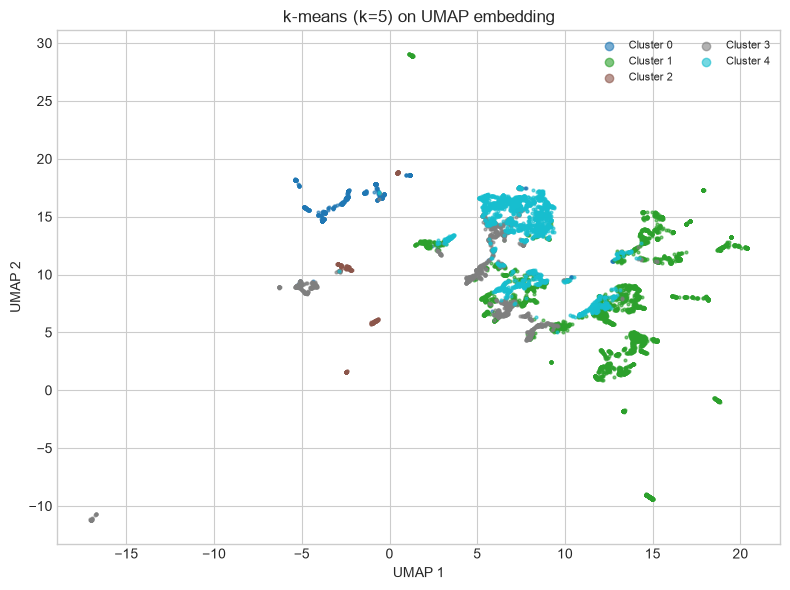

In [19]:
# Cell E2
# LECTURE DEMO
km_best = KMeans(n_clusters=best_k, n_init=20, random_state=SEED)
km_labels = km_best.fit_predict(Z10)

fig, ax = plt.subplots(figsize=(8, 6))
cmap_k = plt.get_cmap('tab10', best_k)
for k in range(best_k):
    mask_k = km_labels == k
    ax.scatter(embedding[mask_k, 0], embedding[mask_k, 1],
               c=[cmap_k(k)], s=4, alpha=0.6, label=f'Cluster {k}')
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
ax.set_title(f'k-means (k={best_k}) on UMAP embedding')
ax.legend(fontsize=8, markerscale=3, ncol=2)
plt.tight_layout()
plt.savefig('E2_kmeans_umap.png', dpi=150)
plt.show()

### E3: GMM - soft clustering

GMM BIC: 276637.0
GMM converged: True


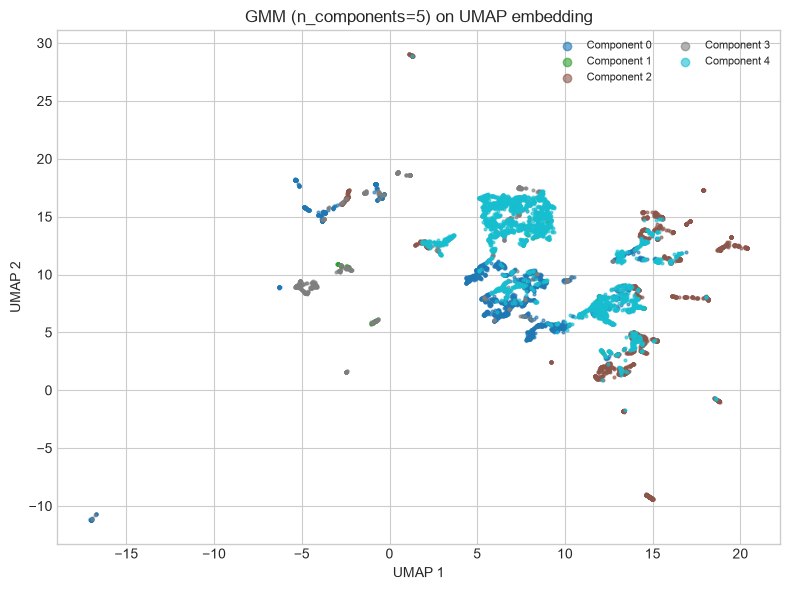

In [20]:
# Cell E3
# LECTURE DEMO
gmm = GaussianMixture(n_components=best_k, covariance_type='full',
                      random_state=SEED, max_iter=200)
gmm.fit(Z10)
gmm_labels = gmm.predict(Z10)
gmm_proba  = gmm.predict_proba(Z10)   # shape (n, best_k)

print(f"GMM BIC: {gmm.bic(Z10):.1f}")
print(f"GMM converged: {gmm.converged_}")

fig, ax = plt.subplots(figsize=(8, 6))
for k in range(best_k):
    mask_k = gmm_labels == k
    ax.scatter(embedding[mask_k, 0], embedding[mask_k, 1],
               c=[cmap_k(k)], s=4, alpha=0.6, label=f'Component {k}')
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
ax.set_title(f'GMM (n_components={best_k}) on UMAP embedding')
ax.legend(fontsize=8, markerscale=3, ncol=2)
plt.tight_layout()
plt.show()

### E4: DBSCAN - density-based clustering

DBSCAN clusters: 38  (noise fraction: 87.0%)


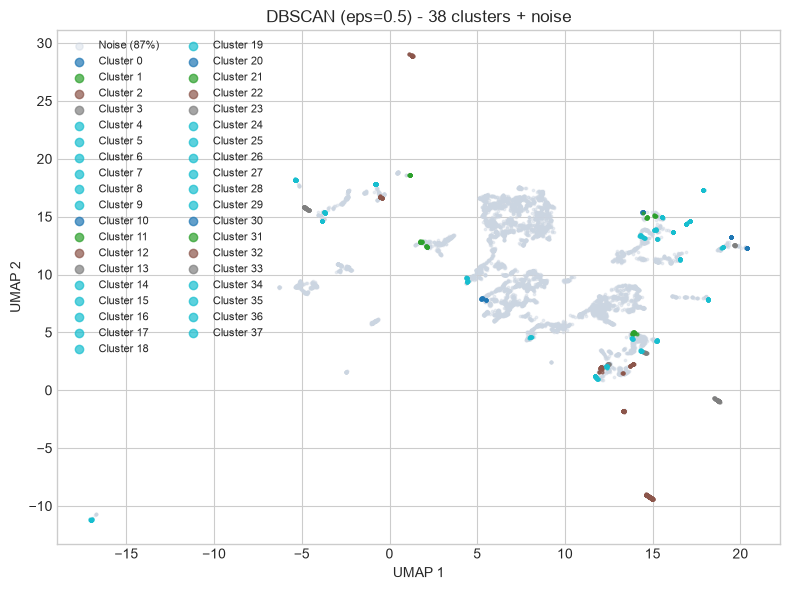

In [21]:
# Cell E4
# LECTURE DEMO
db = DBSCAN(eps=0.5, min_samples=10)
db_labels = db.fit_predict(Z10)

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
noise_frac = (db_labels == -1).mean()

print(f"DBSCAN clusters: {n_clusters_db}  (noise fraction: {noise_frac:.1%})")

fig, ax = plt.subplots(figsize=(8, 6))
noise_mask = db_labels == -1
ax.scatter(embedding[noise_mask, 0], embedding[noise_mask, 1],
           c='#CBD5E1', s=3, alpha=0.4, label=f'Noise ({noise_frac:.0%})')
for k in range(n_clusters_db):
    mask_k = db_labels == k
    ax.scatter(embedding[mask_k, 0], embedding[mask_k, 1],
               c=[cmap_k(k % 10)], s=4, alpha=0.7, label=f'Cluster {k}')
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
ax.set_title(f'DBSCAN (eps=0.5) - {n_clusters_db} clusters + noise')
ax.legend(fontsize=8, markerscale=3, ncol=2)
plt.tight_layout()
plt.savefig('E4_dbscan_umap.png', dpi=150)
plt.show()

### E5: Task - comparison table + reflection

In [22]:
# Cell E5 - Compute silhouette for each algorithm (ignoring noise for DBSCAN)
# TASK CELL
sil_km  = silhouette_score(Z10, km_labels, sample_size=2000, random_state=SEED)
sil_gmm = silhouette_score(Z10, gmm_labels, sample_size=2000, random_state=SEED)

# For DBSCAN, only score non-noise points
non_noise = db_labels != -1
sil_db = silhouette_score(Z10[non_noise], db_labels[non_noise],
                          sample_size=min(2000, non_noise.sum()), random_state=SEED) if non_noise.sum() > 10 else float('nan')

# YOUR CODE: build a comparison table (e.g. a pandas DataFrame) with one row
# per algorithm (K-Means, GMM, DBSCAN) and at least two columns:


comparison_table = pd.DataFrame({
    'Algorithm': ['K-Means', 'GMM', 'DBSCAN'],
    'Silhouette Score': [sil_km, sil_gmm, sil_db],
    'Number of Clusters': [len(set(km_labels)), len(set(gmm_labels)), len(set(db_labels)) - (1 if -1 in db_labels else 0)]
})

# Print the table
print(comparison_table)


  Algorithm  Silhouette Score  Number of Clusters
0   K-Means          0.249477                   5
1       GMM          0.110808                   5
2    DBSCAN          0.752125                  38


**Reflection E5 - fill in this cell:**

Which algorithm produced clusters that best match the visual structure you can see in the UMAP? Does the algorithm with the highest silhouette score also produce the most chemically interpretable clusters? Why or why not?

K-means produced the best match to the visual structure in UMAP. The algorithm with the highest score, which is DBSCAN, is not the most chemically interpretable. This is because it generated a large number of clusters which makes annotation difficult and it was only run on non-noise points which gave it an artifically high score even though it's evident visually that the remaining clusters are small and spread far apart. This makes them hard to interpret. 

---
## Part F - Cluster Annotation

### F1: Per-cluster statistics table

In [23]:
# Cell F1
# LECTURE DEMO
df_clean['km_cluster'] = km_labels
cluster_stats = df_clean.groupby('km_cluster').agg(
    n           = ('formula', 'count'),
    mean_bg     = ('band_gap',    'mean'),
    mean_Ef     = ('Ef_eV_atom', 'mean'),
    top_crystal = ('crystal_system', lambda x: x.mode()[0] if len(x) > 0 else 'Unknown'),
).round(3)

print("Per-cluster statistics:")
print(cluster_stats.to_string())

print("\nTop 5 formulas per cluster:")
for k in range(best_k):
    top5 = df_clean[df_clean['km_cluster']==k]['formula'].value_counts().head(5)
    print(f"  Cluster {k}: {', '.join(top5.index.tolist())}")

Per-cluster statistics:
               n  mean_bg  mean_Ef top_crystal
km_cluster                                    
0            465    1.407   -2.570   Triclinic
1           3592    1.531   -2.327  Monoclinic
2            254    1.607   -1.870  Monoclinic
3           1374    1.915   -2.053  Monoclinic
4           2315    1.825   -2.829  Monoclinic

Top 5 formulas per cluster:
  Cluster 0: FeOF, Mn6O5F7, V3(O2F)2, V3O5F, Mn12O7F17
  Cluster 1: Li9Mn2Co5O16, Li7Mn5O12, Li7Mn4CoO12, LiMnPO4, Li6V3P8O29
  Cluster 2: Li2VO2F, Li2MnO2F, K2O, Na2MnO2, Li3BiO3
  Cluster 3: SiO2, AlPO4, VPO5, FePO4, LiBiP2O7
  Cluster 4: LiSiBiO4, SrZrO3, Sr2MnNbO6, ZrO2, Ba3Cr2O8


### F2: Identify the wide-bandgap cluster

In [24]:
# Cell F2
# LECTURE DEMO
wide_gap_cluster = cluster_stats['mean_bg'].idxmax()
print(f"Cluster with highest mean band gap: Cluster {wide_gap_cluster}")
print(f"  Mean band gap: {cluster_stats.loc[wide_gap_cluster,'mean_bg']:.2f} eV")
print(f"  n entries:     {cluster_stats.loc[wide_gap_cluster,'n']}")
print()
top10_wg = (df_clean[df_clean['km_cluster']==wide_gap_cluster]
            ['formula'].value_counts().head(10))
print("Top 10 formulas:")
print(top10_wg)

Cluster with highest mean band gap: Cluster 3
  Mean band gap: 1.92 eV
  n entries:     1374

Top 10 formulas:
formula
SiO2        58
AlPO4        8
VPO5         8
FePO4        7
LiBiP2O7     6
WO3          5
Fe(PO3)4     5
Sb(PO3)4     5
Bi2O3        5
CoPO4        4
Name: count, dtype: int64


**Reflection F2:**

Based on the top formulas, what chemical family does this wide-bandgap cluster represent? (e.g. alkaline earth oxides, rare earth sesquioxides, main group oxides?) Why does this family have large bandgaps? What is the bonding mechanism?

This wide-bandgap cluster represents the chemical family of main group oxides. This family has large bandgaps because the oxides consist of metals/metalloids with  valence electrons at a higher energy than the p valence electons of the non-metals they are bonded with. This creates a gap between the valence band which is primarily formed by the non-metals and the conduction band formed by the orbitals of the metals/metalloids.The transistion metals like Fe are bonded to phosphate groups that preserve an electronic structure similar to the SiO2 and AlPO4. The bonding mechanism here is primarily covalent with some ionic character. 


### F3: Identify the most thermodynamically stable cluster

In [25]:
# Cell F3
# LECTURE DEMO
stable_cluster = cluster_stats['mean_Ef'].idxmin()
print(f"Most stable cluster: Cluster {stable_cluster}")
print(f"  Mean Ef: {cluster_stats.loc[stable_cluster,'mean_Ef']:.3f} eV/atom")
top10_st = (df_clean[df_clean['km_cluster']==stable_cluster]
            ['formula'].value_counts().head(10))
print("Top 10 formulas:")
print(top10_st)

Most stable cluster: Cluster 4
  Mean Ef: -2.829 eV/atom
Top 10 formulas:
formula
LiSiBiO4     9
SrZrO3       5
Sr2MnNbO6    5
ZrO2         4
Ba3Cr2O8     4
CsSO4        4
TbCeO4       4
Sr4Nb2O9     4
LiP3W2O13    4
Sr4Ta2O9     3
Name: count, dtype: int64


**Reflection F3:**

What chemical family corresponds to the most thermodynamically stable cluster? Why are these compounds more stable than average: ionic radii, oxidation states, crystal structure?

The chemical family that corresponfs to the most thermodynamically stable cluster is that of alkalai metal and alkaline earth metal oxides. They are more stable than average because of strong ionic bonding due to electronegativity difference and favorable oxidation states that help complete the valences of the metals and non-metals involved. The formulas also form perovskite structures which are symmetrical and help lower the energy. 

### F4: Task - produce the final annotated UMAP

> This is the main deliverable of the week. Label each cluster with its chemical family name.

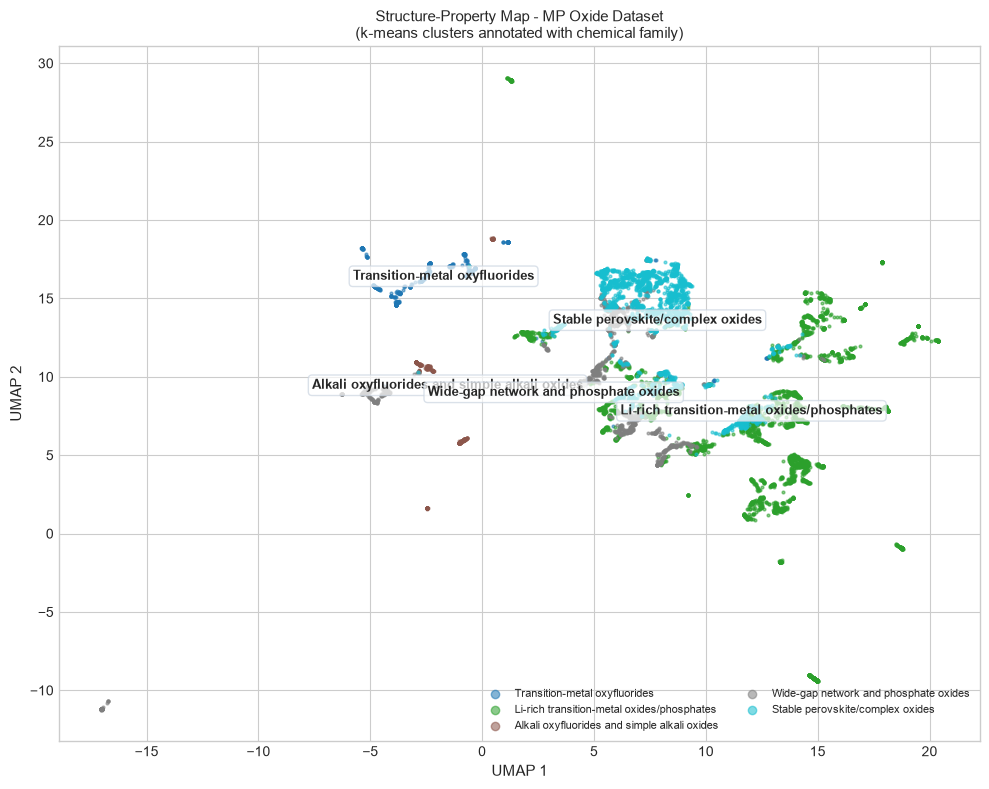

In [26]:
# Cell F4 — Chemical family labels — FILL THESE IN based on your F1-F3 analysis
# TASK CELL
# YOUR CODE: replace the dictionary below with real chemical family names for
# each of the best_k clusters, based on what you found in F1 (per-cluster stats),
# F2 (the wide-bandgap cluster), and F3 (the most thermodynamically stable cluster).
# Example:
# cluster_labels = {0: 'Transition metal oxides', 1: 'Wide-gap insulators',
#                   2: 'Rare earth oxides', 3: 'Alkaline earth oxides', ...}
cluster_labels = {
    0: 'Transition-metal oxyfluorides',
    1: 'Li-rich transition-metal oxides/phosphates',
    2: 'Alkali oxyfluorides and simple alkali oxides',
    3: 'Wide-gap network and phosphate oxides',
    4: 'Stable perovskite/complex oxides'
}

# ── Plotting code below is given — do not need to modify ─────────────────────
fig, ax = plt.subplots(figsize=(10, 8))

for k in range(best_k):
    mask_k = km_labels == k
    ax.scatter(embedding[mask_k, 0], embedding[mask_k, 1],
               c=[cmap_k(k)], s=4, alpha=0.55,
               label=cluster_labels[k])
    # Centroid annotation
    cx = embedding[mask_k, 0].mean()
    cy = embedding[mask_k, 1].mean()
    ax.annotate(cluster_labels[k],
                xy=(cx, cy), fontsize=9, fontweight='bold',
                ha='center',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7, ec='#CBD5E1'))

ax.set_xlabel('UMAP 1', fontsize=11)
ax.set_ylabel('UMAP 2', fontsize=11)
ax.set_title('Structure-Property Map - MP Oxide Dataset\n(k-means clusters annotated with chemical family)', fontsize=11)
ax.legend(fontsize=8, markerscale=3, ncol=2)
plt.tight_layout()
plt.savefig('F4_annotated_umap.png', dpi=150)
plt.show()

---
## Part G - Reflection

### G1: PCA biplot - physical interpretation

In 3–4 sentences, answer: what do the top loading features on PC1 and PC2 tell you about the dominant sources of compositional variation in the MP oxide dataset? Name the specific MAGPIE features, and for each one explain physically why that descriptor captures a major axis of variation.

The top features for PC1 and PC2 tell me that dominant sources of compositional variance in the MP oxide dataset are causing variation by influencing the electronic structure of the oxide or by influencing the size of the atoms in the oxide. Mean Nvalence captures variation in PC1 because it changes with different cation/anion combinations as you move from alkaline metals through metalloids horizontally across the periodic table. Avg_dev atomic number and avg_dev atomic weight are capturing the variation in the elements present within the chemical formula. 

Mean Covalent radius, avg_dev covalent radius, and mean column are capturing variation in PC2 because these are changing with atomic size and periodic table family. Mean covalent radius changes as the cations come from different families across the periodic table or as the radius changes with a group. avg_dev covalent radius captures variation between the elements present whether that be the cation-anion radius deviation or also cation-cation radius deviation. Mean column is capturing a similar trend of changing the family of the elements present in the oxide. 

### G2: Cluster validation

In 3–4 sentences, describe one cluster from your annotated UMAP that you are confident represents a genuine chemical family (not an algorithm artefact). State: (1) its chemical family name, (2) its mean band_gap and Ef, (3) why the MAGPIE features that load onto the relevant PCA axis would group these materials together, and (4) one test you could do to confirm the cluster is chemically real.

Of the clusters, the one that is closest to representing a real chemical family is Cluster 4: Stable Perovskites/Complex Oxides. Its mean bandgap is 1.825 eV and the mean Ef is -2.829 eV. The MAGPIE features that load on PC1 and PC2 group these together because mean valence and avg_dev in atomic weight are similar as are the mean/avg_dev in covalent radius. The valences for the transition metals are close and there are large deviations in the radius between cations within the formulas. 

One test to confirm the cluster is real would be to use x-ray diffraction and look for the same pattern of peaks. 

### G3: Final project connection

Would PCA or UMAP be useful as an analysis step in your final project? In 3–4 sentences: (1) what material class or property are you studying, (2) what structure would you expect to find in the composition space of your materials, and (3) what would a dense cluster vs. a sparse region of the UMAP tell you scientifically?

PCA could be useful because it could tell me what subset of features causes the most variation bewteen my datapoints which could be useful when paired with a linear model or Random forest regressor. UMAP could  also be useful if it shows the different test conditions from the CALCE data clustering together. The property I'm studying is energy capacity of lithium battery cells in operation. I think that UMAP will tend to cluster by test condtions and the points in each cluster will be the individual cycles. 

A dense cluster would tell me that cycles are very similar in nature and a sparse cluster would tell me there is alot of variation between cycles. 

---
## Day 2 Demo

> **This section is covered during the Day 2 session.**

### Demo 1 - Preview: what UMAP will look like

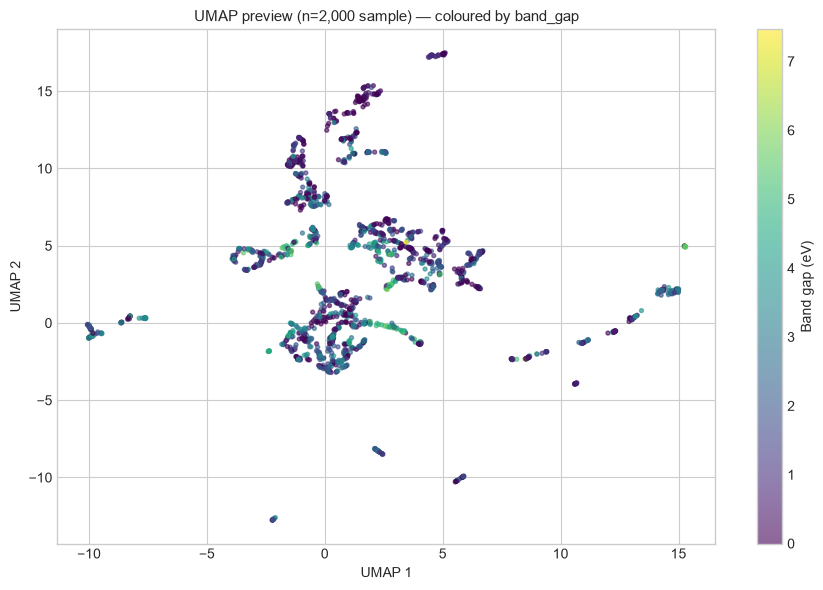

Run the full UMAP on all entries in your Part D.


In [27]:
# Cell DEMO 1 - Quick UMAP preview (n_neighbors=15, subsample for speed)
# LECTURE DEMO

import numpy as np
import matplotlib.pyplot as plt
try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    print("umap-learn not installed. Run: pip install umap-learn")
    UMAP_AVAILABLE = False

if UMAP_AVAILABLE:
    # Subsample for the live demo — full UMAP takes 3-5 min
    sample_idx = np.random.RandomState(42).choice(len(X_scaled),
                                                   min(2000, len(X_scaled)),
                                                   replace=False)
    X_sample = X_scaled[sample_idx]

    reducer_preview = umap.UMAP(n_components=2, n_neighbors=15,
                                min_dist=0.1, random_state=42)
    emb_preview = reducer_preview.fit_transform(X_sample)

    bg_sample = df_clean['band_gap'].values[sample_idx]                 if 'band_gap' in df_clean.columns else np.zeros(len(sample_idx))

    fig, ax = plt.subplots(figsize=(9, 6))
    sc = ax.scatter(emb_preview[:,0], emb_preview[:,1],
                    c=bg_sample, cmap='viridis', s=8, alpha=0.6)
    plt.colorbar(sc, ax=ax, label='Band gap (eV)')
    ax.set_title(f'UMAP preview (n={len(sample_idx):,} sample) — coloured by band_gap',
                 fontsize=11)
    ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
    plt.tight_layout()
    plt.savefig('Day2_umap_preview.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Run the full UMAP on all entries in your Part D.")

**Day 2 Discussion questions:**

1. From Demo 1: in the UMAP preview, do you see distinct clusters or a continuous manifold? Which part of composition space do you expect to occupy each cluster? Your Part D will run this on the full dataset.

I see distinct clusters. I expect the clusters to be occupied by the same composition clusters identified in F4. 

---
## Submission Checklist

Before submitting, confirm all cells have been executed:

- [ ] B1: Scree plot saved (`B1_scree.png`)
- [ ] B2: Biplot saved (`B2_biplot.png`)
- [ ] B4: Band-gap biplot saved and reflection filled in
- [ ] C1–C2: PCA projection scatters saved
- [ ] C3: PC3/PC4 scatter saved and reflection filled in
- [ ] D1: UMAP embedding saved (`D1_umap_embedding.npy`)
- [ ] D2–D4: Three UMAP scatters saved
- [ ] D5: n_neighbors comparison saved and reflection filled in
- [ ] E1: Elbow + silhouette saved; optimal k reported
- [ ] E2–E4: All three clustering results on UMAP saved
- [ ] E5: Comparison table printed and reflection filled in
- [ ] F1–F3: Per-cluster stats printed; reflections filled in
- [ ] F4: Annotated UMAP saved (`F4_annotated_umap.png`) with real chemical family labels
- [ ] G1–G3: All reflection cells answered
- [ ] All reflection cells answered (no placeholder text)
- [ ] AI disclosure note updated or deleted at the top of the notebook
- [ ] File renamed: `[LastName]_week9.ipynb`
**Final check:** Run `Kernel → Restart & Run All`. All cells must execute without errors before submitting.
**Submit via Canvas by Sunday 11:59 PM.**